# 03b-02 - Feature Detection

You see what a feature is: a spot that can be found again, with a position, a size and a description.

We count the features the software kept in every photograph of the flight. Then we find corners by hand in one photograph, zoom in on the building's corner, and count them inside the field against outside. A second detector gives each spot a size. Last we open the software's features and take one description apart.

This notebook reads the flight named in `data/flight.json`. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that the next pull never collides with your work.

In [1]:
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import sfm_tools as sfm
from shapely.geometry import Point, Polygon, box

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight, choices = sfm.load_flight("data/flight.json")
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at "
      f"{flight['altitude_agl_m']} m, {flight['n_photos']} photographs")

the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs


## Features in every photograph

The cell reads the software's report and draws how many features it kept in each photograph, in the order the photographs were taken.

4629 features per photograph on average   reference 4629
fewest 856, most 7530   reference 856, 7530


Text(0, 0.5, 'features kept')

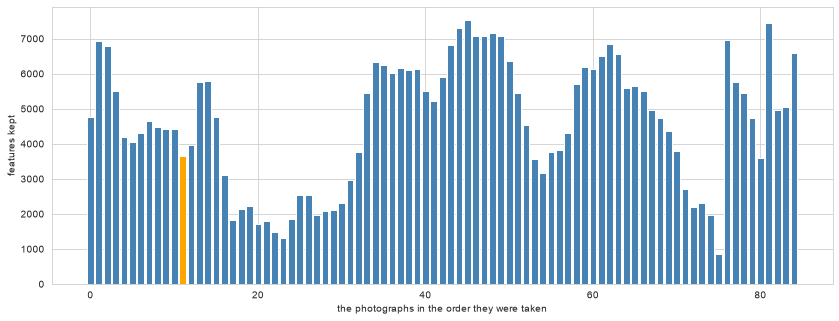

In [2]:
report = json.load(open("data/report.json"))
photos = pd.read_csv("data/photos.csv").sort_values("time_utc")
kept = photos["file"].map(report["features_kept_per_image"])
per = reference["features"]["per_photograph"]
print(f"{int(kept.mean())} features per photograph on average   reference {per['mean']:.0f}")
print(f"fewest {kept.min()}, most {kept.max()}   reference {per['min']:.0f}, {per['max']:.0f}")
colours = np.where(photos["file"] == choices["photos"]["a"]["name"], "orange", "steelblue")
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(kept)), kept, color=colours)
ax.set_xlabel("the photographs in the order they were taken")
ax.set_ylabel("features kept")

The software found a few thousand features in every photograph. Some photographs have more than others. Look at the low bars and ask what those photographs show. A frame full of lawn gives a detector little to hold on to, a frame with roofs, paths and trees gives it plenty. The orange bar is the photograph the rest of this notebook works on. Everything that follows is about that one photograph, but the count is the same story for all.

## Corners by hand

The cell finds the strongest corners of photo a with a classic detector and zooms in on the building's corner, placed in the picture at the roof's height.

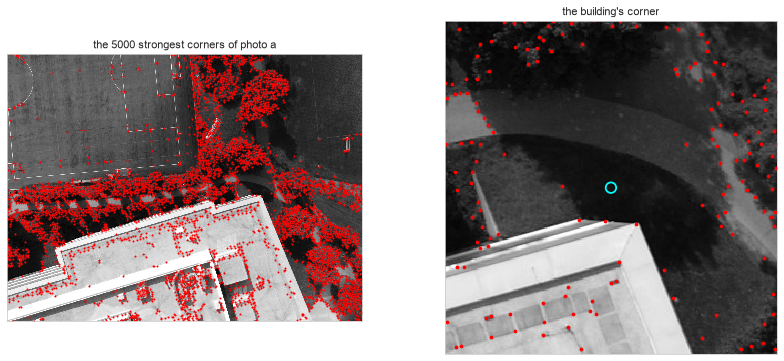

In [3]:
gray = sfm.read_image("data/photo_a.jpg", gray=True)
rows, cols, strength = sfm.harris(gray, n=5000)
block = sfm.load_block("data/block.npz")
dsm, transform, crs, cell = sfm.read_raster("data/dsm_window.tif")
roof = sfm.roof_mask(sfm.roof_polygon(choices), transform, dsm.shape)
corner = Point(*sfm.roof_corner(choices)).buffer(0.01)   # a tiny disc, projected like an outline
u_c, v_c = sfm.project_outline(block, choices, "a", corner, float(np.nanmedian(dsm[roof])))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sfm.show_image(axes[0], gray, title=f"the {len(rows)} strongest corners of photo a")
axes[0].scatter(cols, rows, s=4, color="red", linewidths=0)
crop = sfm.crop_at(axes[1], gray, u_c.mean(), v_c.mean(), half=150, title="the building's corner")
axes[1].scatter(cols, rows, s=14, color="red", linewidths=0)

A corner is a place where the picture changes in two directions at once. A lawn changes in none. An edge changes in one, so you could slide along it. Look at the zoom. The dots sit on the roof's vents and joints, along its bright rim, on the kerbs of the path and in the crowns. The shaded lawn carries none. The ring is the building's corner from the map, which knows the walls, not the roof. The roof's own corner lies below it in the zoom.

## Inside the field and outside

The cell projects the field's outline into the photograph at the ground's height, and counts the corners inside it and outside it per megapixel.

518 corners inside the field and 4482 outside
1085 and 1777 corners per megapixel
reference {'inside_field': 518, 'outside_field': 4482, 'per_megapixel_inside': 1085.0, 'per_megapixel_outside': 1777.0}


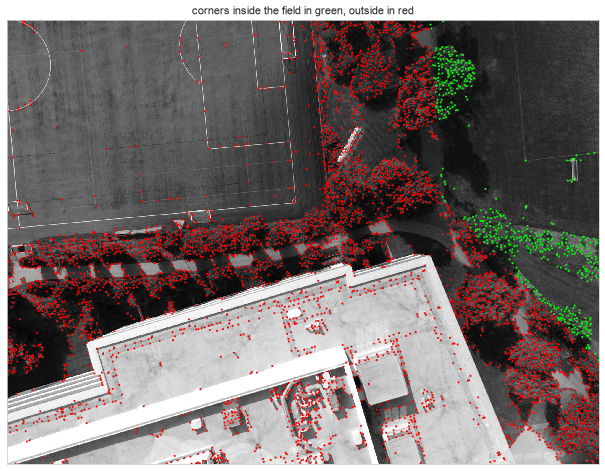

In [4]:
field = gpd.read_file("data/site.gpkg", layer="site").to_crs(choices["crs"]).geometry.iloc[0]
dtm, transform, crs, cell = sfm.read_raster("data/dtm_window.tif")
u_f, v_f = sfm.project_outline(block, choices, "a", field, float(np.nanmedian(dtm)))
in_field = sfm.inside(u_f, v_f, cols, rows)
mp_in = Polygon(zip(u_f, v_f)).intersection(box(0, 0, gray.shape[1], gray.shape[0])).area / 1e6
mp_out = gray.size / 1e6 - mp_in   # megapixels of the frame inside the field and outside it
print(f"{in_field.sum()} corners inside the field and {(~in_field).sum()} outside")
print(f"{in_field.sum() / mp_in:.0f} and {(~in_field).sum() / mp_out:.0f} corners per megapixel")
print("reference", reference["features"]["harris_top5000"])
fig, ax = plt.subplots(figsize=(14, 8))
sfm.show_image(ax, gray, title="corners inside the field in green, outside in red")
ax.scatter(cols, rows, s=4, c=np.where(in_field, "lime", "red"), linewidths=0)

The field is the question of this flight. Count per megapixel, because the field is only part of the frame. Read the two numbers against each other. The lawn is not empty. Part of the green sits on the crowns along the edge, the rest is the lawn's own stripes and wear, which at this pixel size are texture. What the count does not say is how strong those corners are, or whether they can be found again in the next photograph. The your turn asks the first question.

## Size and direction

The cell runs a second detector on the zoom, one that blurs the picture a little and a little more, and draws each blob at the size that answered.

69 blobs, radii from 2.7 to 15.2 pixels


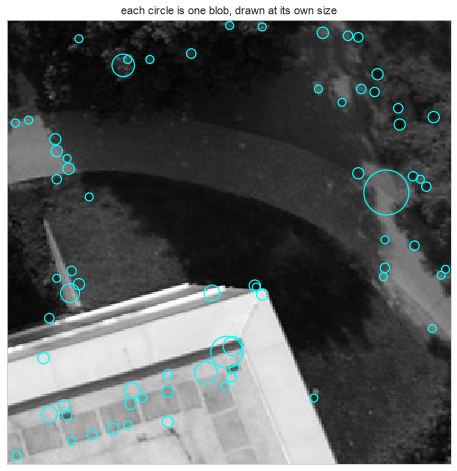

In [5]:
blobs = sfm.dog_blobs(crop)
radius = np.sqrt(2) * blobs[:, 2]   # a blob's size is about 1.4 times its blur width
print(f"{len(blobs)} blobs, radii from {radius.min():.1f} to {radius.max():.1f} pixels")
fig, ax = plt.subplots(figsize=(8, 8))
sfm.show_image(ax, crop, title="each circle is one blob, drawn at its own size")
for x, y, r in zip(blobs[:, 0], blobs[:, 1], radius):
    ax.add_patch(plt.Circle((x, y), r, fill=False, color="cyan", linewidth=1.2))

A corner has a position but no size. A vent or a shrub has a size. The detector blurs the picture a little and a little more and subtracts the two. A blob answers at the blur that fits it, and each circle is that size. Look at the big circle on the shrub and the small ones on the roof's vents and joints. A feature carries its size and its direction, so that it can be found again from another height or heading.

## The software's features and the descriptor

The cell opens the features the software kept for photo a, draws them on the photograph, and takes apart the description of the one nearest the building's corner.

3664 features kept in photo a   reference 3664
128 numbers each, 0 to 148   reference 0 to 148


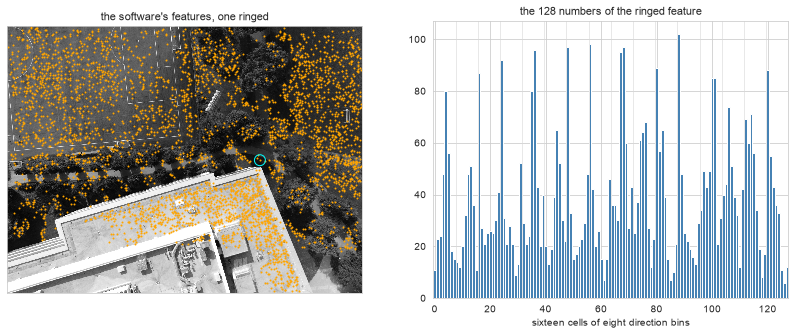

In [6]:
features = sfm.load_features("data/features_pair.npz")
u_a, v_a = sfm.feature_pixels(features["points_a"], gray.shape[1], gray.shape[0])
nearest = int(np.argmin(np.hypot(u_a - u_c.mean(), v_a - v_c.mean())))
desc = features["descriptors_a"]
low, high = reference["features"]["descriptor_range"]
print(f"{len(u_a)} features kept in photo a   reference {reference['features']['pair']['a']}")
print(f"{desc.shape[1]} numbers each, {desc.min()} to {desc.max()}   reference {low} to {high}")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sfm.show_image(axes[0], gray, title="the software's features, one ringed")
axes[0].scatter(u_a, v_a, s=4, color="orange", linewidths=0)
axes[0].scatter(u_a[nearest], v_a[nearest], s=120, facecolor="none", edgecolor="cyan")
sfm.descriptor_bars(axes[1], desc[nearest], title="the 128 numbers of the ringed feature")

These are the features the software kept. Each has 128 numbers describing the patch around it, as sixteen cells of eight directions. In each cell the numbers say how much the picture changes in each direction. Two patches of the same spot give nearly the same bars, from any height or heading, because the patch is measured at the feature's own size and turned to its own direction. This is what gets matched in the next notebook, not the pixels.

## Your turn

Repeat the count of corners inside the field and outside it for the strongest thousand corners instead of the strongest five thousand. Run the cell as it is, then change the marked value and run it again.

What changed between the two counts, and what does that say about the lawn? Write your answer in one or two sentences. The answer comes in Friday's post, not in the kit.

In [7]:
N_CORNERS = 5000  # change me: 1000
rows_n, cols_n, strength_n = sfm.harris(gray, n=N_CORNERS)
inside_n = sfm.inside(u_f, v_f, cols_n, rows_n)
print(f"{inside_n.sum()} of the {N_CORNERS} corners inside the field, {(~inside_n).sum()} outside")
print(f"{inside_n.sum() / mp_in:.0f} and {(~inside_n).sum() / mp_out:.0f} corners per megapixel")

518 of the 5000 corners inside the field, 4482 outside
1085 and 1777 corners per megapixel


## Check your understanding

1. A lawn, an edge and a corner differ in how the picture changes around them. Say what changes in each case, and which one a matcher can use.
2. Why must a feature carry a size? Say what would go wrong when matching two flights of this site flown at different heights.
3. The descriptor is measured at the feature's size and turned to its direction. Name two changes between two photographs it survives, and one it does not.
4. The field had fewer corners per megapixel than the rest, but not none. What does that say about the lawn, and what can it not say yet?

## Where we are

You found corners in a photograph and saw where they sit, counted them inside the field against the rest, and gave each spot a size with a second detector. You now know that a feature is a position with a size, a direction and a description of 128 numbers, and that the description, not the pixels, is what matching compares. In 03b-03 we match these features between two photographs and join the matches into tracks.

## Further resources

Nothing in this course requires anything below.

- A combined corner and edge detector, Harris and Stephens, Alvey Vision Conference, 1988.
- Distinctive image features from scale-invariant keypoints, Lowe, International Journal of Computer Vision, 2004: https://www.cs.ubc.ca/~lowe/papers/ijcv04.pdf
- Computer Vision: Algorithms and Applications, Szeliski, Springer, 2022, chapter 7, free online: https://szeliski.org/Book/
- OpenSfM documentation, the feature types and the normalised image coordinates: https://opensfm.org/docs/

The photographs, the software's files and the products are the course's own flight, published under CC BY 4.0. The outline of Poe Field and the buildings are an OpenStreetMap extract, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright